In [1]:
! pip install scikit-learn

In [1]:
import re
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy import random
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, precision_recall_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2025-08-07 15:10:16.138492: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-07 15:10:16.930412: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-07 15:10:16.930721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-07 15:10:17.054421: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-07 15:10:17.341536: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-07 15:10:17.349783: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
class SepsisCDSSystem:

    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")

    def loadDataset (self, path):
       return pd.read_csv(path)

    def mergeData (self, category):
        df = pd.concat(category, ignore_index=True)
        return df.sample(frac=1, random_state=42)

    def MLCategorizer (self, dataset, x, y):
        return train_test_split(dataset[x], dataset[y],random_state=104,test_size=0.25, shuffle=True)

    def classifier (self, X_train, y_train):
        self.clf = Pipeline([
            ("vectorizer", CountVectorizer()),
            ("np", MultinomialNB())
        ])
        self.clf.fit(X_train, y_train)
        return self.clf

    def analizeReport (self, X_test, y_test):
        pre_training = self.clf.predict(X_test)
        return classification_report(y_test, pre_training)

    def predictText (self, text):
        return self.clf.predict([text])

    def knnClassifier (self, X_train, y_train):
        self.knnClf = self.knn.fit(X_train, y_train)
        return self.knnClf

    def convertTextToVec (self, text):
        # print(text)
        doc = self.nlp(str(text).lower())
        return doc.vector

    def stackVector (self, vector):
        return np.stack(vector)

    def predictTextWithKNN (self, vector):
        return self.knnClf.predict(vector)

    def analizeTextWithKNN (self, pred, data):
        return classification_report(data, pred)

    def mapLabel (self, text):
      if text == "NNS":
        return 1
      elif text == "PROBABLE-NNS":
        return 2
      elif text == "LATE-NNS":
        return 3
      elif text == "EARLY-NNS":
        return 4
      else:
        return 0

    def clean_and_convert_age_to_hours(self, age_text):

      if pd.isnull(age_text):
          return None  # handle NaNs safely

      # Step 1: Remove spaces and lowercase
      age_text = age_text.replace(' ', '').lower()

      # Step 2: Extract number and unit
      match = re.match(r'(\d+)([a-z]+)', age_text)
      if not match:
          return None  # if format is wrong

      number, unit = match.groups()
      number = int(number)

      # Step 3: Convert based on unit
      if unit in ['dy', 'dys', 'day', 'days']:
          return number * 24
      elif unit in ['hr', 'hrs', 'hour', 'hours']:
          return number
      elif unit in ['min', 'mins', 'minute', 'minutes']:
          return number
      elif unit in ['wk', 'wks', 'week', 'weeks']:
          return number * 7 * 24
      elif unit in ['mo', 'mos', 'month', 'months']:
          return number * 30 * 24
      elif unit in ['yr', 'yrs', 'year', 'years']:
          return number * 365 * 24
      else:
          return None  # unknown unit

  # clean_and_convert_age_to_hours("6wks")

In [3]:
cdsSystem = SepsisCDSSystem()
dataset = cdsSystem.loadDataset("augmented-dataset-2.csv")

dataset["DIAGNOSIS"].value_counts()

DIAGNOSIS
EARLY-NNS       581
NNS             529
LATE-NNS        513
PROBABLE-NNS    461
Name: count, dtype: int64

In [4]:
df = dataset

df["symptoms-age"] = df["SYMPTOMS"] + " " + df["AGE"]

df["symptoms"] = df["symptoms-age"].apply(lambda text: cdsSystem.convertTextToVec(text))

df["diagnosis"] = df["DIAGNOSIS"].apply(lambda text: cdsSystem.mapLabel(text))

# df["age"] = df["AGE"].apply(lambda text: cdsSystem.clean_and_convert_age_to_hours(text))

In [6]:
df.describe()

,diagnosis
count,2094.000000
mean,2.537727
std,1.156737
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,4.000000


In [5]:
X_train, X_test, y_train, y_test = cdsSystem.MLCategorizer(df, "symptoms", "diagnosis")

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1570,), (524,), (1570,), (524,))

In [6]:
X_train = cdsSystem.stackVector(X_train)
X_test = cdsSystem.stackVector(X_test)

In [9]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
kkn_report = classification_report(y_test, knn_pred)

print(kkn_report)

knn_accuracy_score = accuracy_score(y_test, knn_pred)
print("ACCURACY: ", str(round(knn_accuracy_score * 100)) + "%")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.69      0.79      0.74       131
           2       0.73      0.58      0.64       111
           3       0.96      0.98      0.97       136
           4       0.97      0.97      0.97       143

    accuracy                           0.84       524
   macro avg       0.87      0.86      0.86       524
weighted avg       0.84      0.84      0.84       524

ACCURACY:  84%


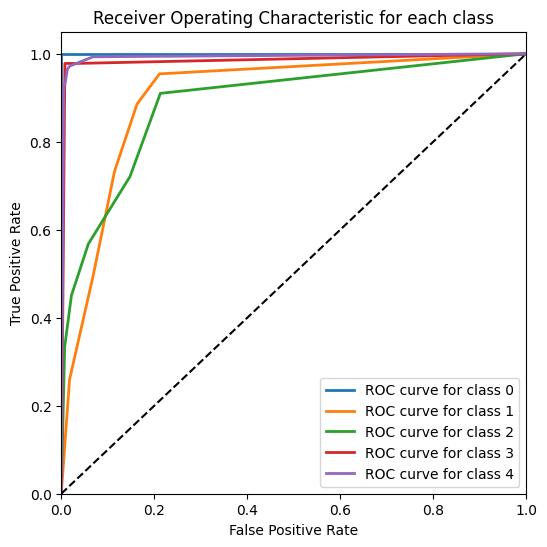

In [10]:
# Compute ROC curve and AUC
# Check if it is a binary classification problem
if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, knn_model.predict_proba(X_test)[:, 1])  # Assuming binary classification.  Corrected y_test
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
else:
    # Use LabelBinarizer to convert y_test to a binary matrix for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], knn_model.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for each class
    plt.figure(figsize=(6, 6))
    for i, class_label in enumerate(np.unique(y_test)):
        plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {}'.format(class_label))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for each class')
    plt.legend(loc="lower right")
    plt.show()


In [11]:
mlp_model = MLPClassifier(hidden_layer_sizes=(160,), random_state=12)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)
mlp_report = classification_report(y_test, mlp_pred)

print(mlp_report)

mlp_accuracy_score = accuracy_score(y_test, mlp_pred)
print("ACCURACY: ", str(round(mlp_accuracy_score * 100)) + "%")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.72      0.74      0.73       131
           2       0.71      0.67      0.69       111
           3       0.96      0.98      0.97       136
           4       0.97      0.97      0.97       143

    accuracy                           0.85       524
   macro avg       0.87      0.87      0.87       524
weighted avg       0.85      0.85      0.85       524

ACCURACY:  85%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


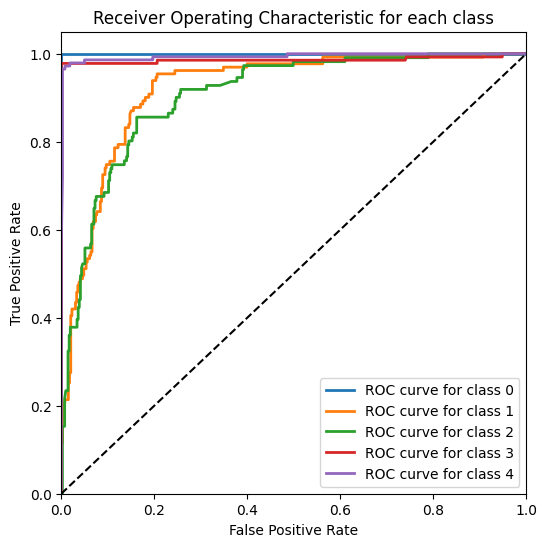

In [12]:
# Compute ROC curve and AUC
# Check if it is a binary classification problem
if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, mlp_model.predict_proba(X_test)[:, 1])  # Assuming binary classification.  Corrected y_test
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
else:
    # Use LabelBinarizer to convert y_test to a binary matrix for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], mlp_model.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for each class
    plt.figure(figsize=(6, 6))
    for i, class_label in enumerate(np.unique(y_test)):
        plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {}'.format(class_label))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for each class')
    plt.legend(loc="lower right")
    plt.show()


In [13]:
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
gnb_pred = gnb_model.predict(X_test)
gnb_report = classification_report(y_test, gnb_pred)

print(gnb_report)

accuracy_gnb = accuracy_score(y_test, gnb_pred)
print("ACCURACY: ", str(round(accuracy_gnb * 100)) + "%")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.65      0.55      0.60       131
           2       0.50      0.59      0.54       111
           3       0.85      0.89      0.87       136
           4       0.94      0.92      0.93       143

    accuracy                           0.75       524
   macro avg       0.79      0.79      0.79       524
weighted avg       0.75      0.75      0.75       524

ACCURACY:  75%


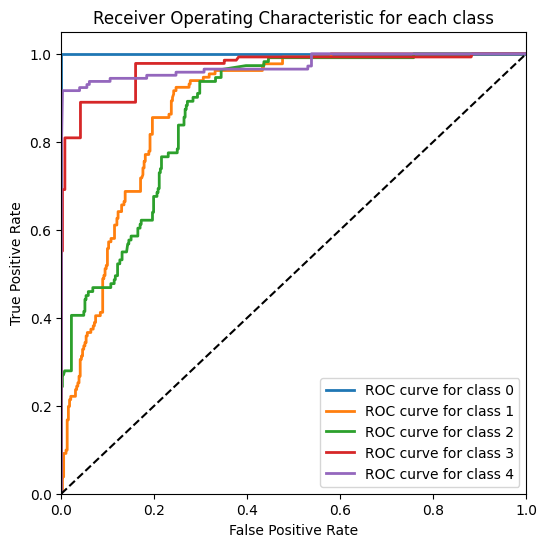

In [14]:
# Compute ROC curve and AUC
# Check if it is a binary classification problem
if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, gnb_model.predict_proba(X_test)[:, 1])  # Assuming binary classification.  Corrected y_test
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
else:
    # Use LabelBinarizer to convert y_test to a binary matrix for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], gnb_model.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for each class
    plt.figure(figsize=(6, 6))
    for i, class_label in enumerate(np.unique(y_test)):
        plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {}'.format(class_label))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for each class')
    plt.legend(loc="lower right")
    plt.show()


In [7]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_report = classification_report(y_test, y_pred_rf)

print(rf_report)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("ACCURACY: ", str(round(accuracy_rf * 100)) + "%")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.69      0.83      0.75       131
           2       0.71      0.59      0.64       111
           3       1.00      0.98      0.99       136
           4       0.99      0.96      0.97       143

    accuracy                           0.85       524
   macro avg       0.88      0.87      0.87       524
weighted avg       0.86      0.85      0.85       524

ACCURACY:  85%


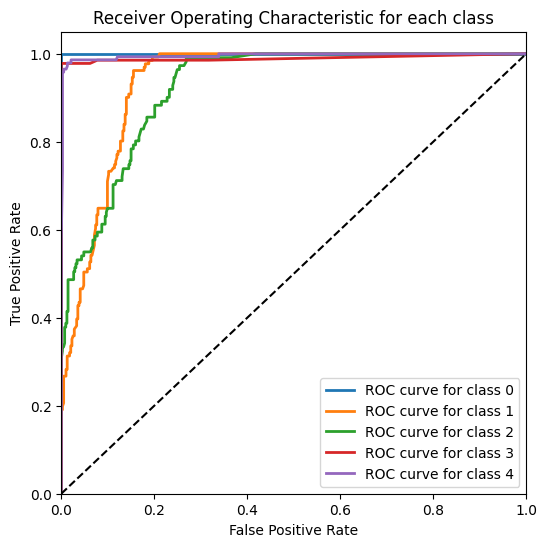

In [16]:
# Compute ROC curve and AUC
# Check if it is a binary classification problem
if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])  # Assuming binary classification.  Corrected y_test
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
else:
    # Use LabelBinarizer to convert y_test to a binary matrix for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], rf_model.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for each class
    plt.figure(figsize=(6, 6))
    for i, class_label in enumerate(np.unique(y_test)):
        plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {}'.format(class_label))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for each class')
    plt.legend(loc="lower right")
    plt.show()


In [17]:
model_names = ['KNN', 'MLP', 'Naive Bayes', 'Random Forest']
accuracies = [knn_accuracy_score, mlp_accuracy_score, accuracy_gnb, accuracy_rf]

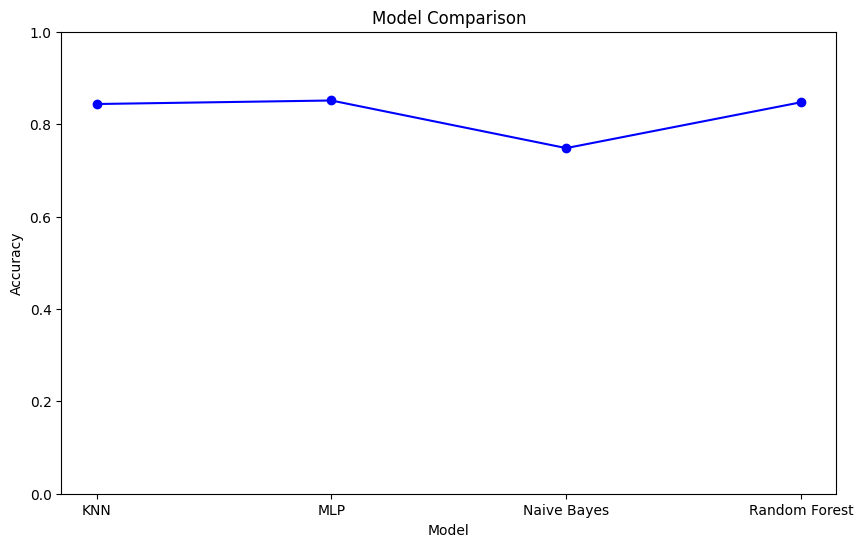

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(model_names, accuracies, marker='o', linestyle='-', color='blue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)  # Set the y-axis limit to be between 0 and 1
plt.show()

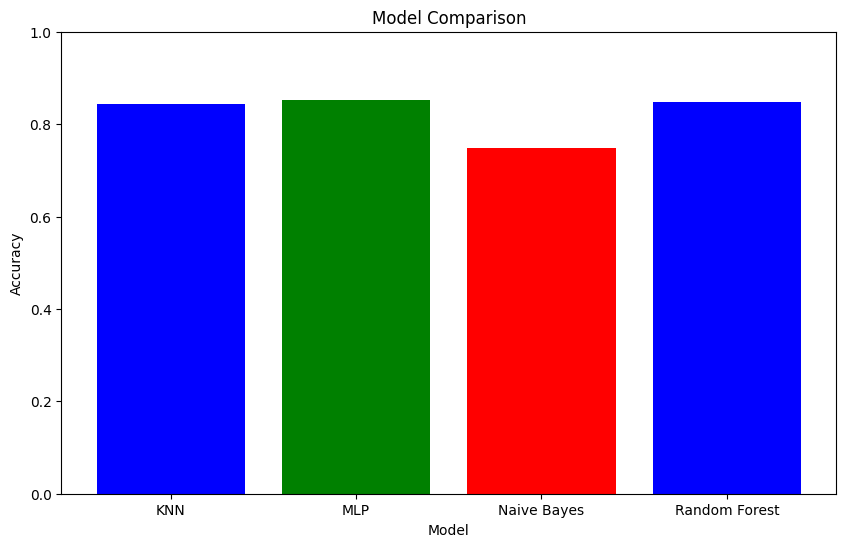

In [19]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)  # Set the y-axis limit to be between 0 and 1
plt.show()

**DEEP LEARNING**

In [20]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['symptoms-age'].astype(str))
X_sequences = tokenizer.texts_to_sequences(df['symptoms-age'].astype(str))
X_padded = pad_sequences(X_sequences)

In [21]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 500

In [22]:
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42, shuffle=True)

In [23]:

# Define the RNN-LSTM model
lstm_model = Sequential()
lstm_model.add(Embedding(vocab_size, embedding_dim, input_length=X_train.shape[1])) # Use X_train.shape[1]
lstm_model.add(LSTM(128))  # You can adjust the number of units
lstm_model.add(Dense(len(y.unique()), activation='softmax'))  # Output layer

# Compile the model
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
print(lstm_model.summary())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [24]:
lstm_training_history = lstm_model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.2)

Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.4714 - loss: 1.1812 - val_accuracy: 0.8000 - val_loss: 0.5078
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7999 - loss: 0.4631 - val_accuracy: 0.8418 - val_loss: 0.3522
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.8422 - loss: 0.3369 - val_accuracy: 0.8537 - val_loss: 0.3304
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8833 - loss: 0.2750 - val_accuracy: 0.8448 - val_loss: 0.3419
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9077 - loss: 0.2453 - val_accuracy: 0.8716 - val_loss: 0.3285
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9294 - loss: 0.1891 - val_accuracy: 0.8716 - val_loss: 0.3840
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9291 - loss: 0.1832 - val_accuracy: 0.8687 - val_loss: 0.3929
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9316 - loss: 0.1843 - val_accuracy: 0.8806 - v

In [25]:
loss, accuracy = lstm_model.evaluate(
          X_test,
          y_test
)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8292 - loss: 1.1492
Test Loss: 1.0470383167266846
Test Accuracy: 0.8353222012519836


In [26]:
y_pred_probabilities = lstm_model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

report = classification_report(y_test, y_pred)
print(report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.78      0.66      0.72       116
           2       0.65      0.71      0.68        90
           3       1.00      0.98      0.99       105
           4       0.90      0.98      0.94       106

    accuracy                           0.84       419
   macro avg       0.86      0.87      0.86       419
weighted avg       0.84      0.84      0.83       419



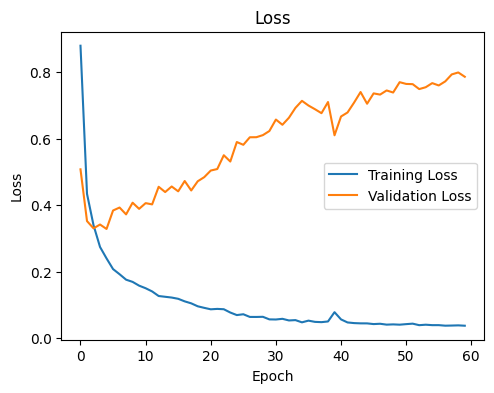

In [27]:
# Plotting the training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(lstm_training_history.history['loss'], label='Training Loss')
plt.plot(lstm_training_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


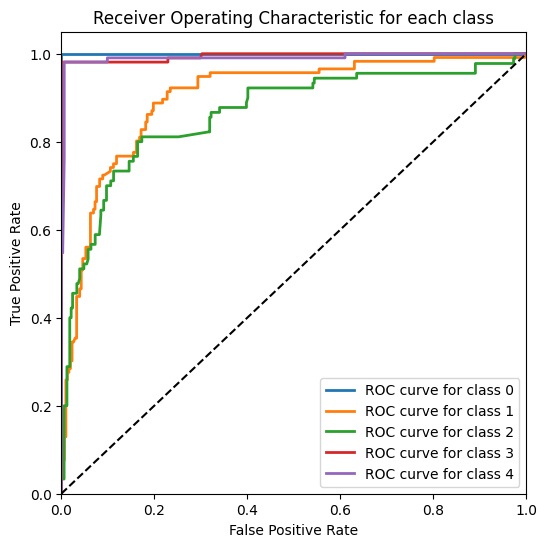

In [28]:
# Compute ROC AUC for LSTM
y_pred_lstm = lstm_model.predict(X_test)
y_pred_lstm_proba = np.zeros_like(y_pred_lstm)
if len(np.unique(y_test)) == 2:
  fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_lstm[:, 1])
  roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
  print(f'\nLSTM ROC AUC: {roc_auc_lstm:.4f}')
  plt.figure(figsize=(6, 6))
  plt.plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, label='LSTM ROC curve (area = %0.2f)' % roc_auc_lstm)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('LSTM Receiver Operating Characteristic')
  plt.legend(loc="lower right")
  plt.show()
else:
    # Use LabelBinarizer to convert y_test to a binary matrix for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    fpr_lstm = dict()
    tpr_lstm = dict()
    roc_auc_lstm = dict()
    for i in range(len(np.unique(y_test))):
        fpr_lstm[i], tpr_lstm[i], _ = roc_curve(y_test_bin[:, i], y_pred_lstm[:, i])
        roc_auc_lstm[i] = auc(fpr_lstm[i], tpr_lstm[i])
    # Plot ROC curve for each class
    plt.figure(figsize=(6, 6))
    for i, class_label in enumerate(np.unique(y_test)):
        plt.plot(fpr_lstm[i], tpr_lstm[i], lw=2, label='ROC curve for class {}'.format(class_label))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for each class')
    plt.legend(loc="lower right")
    plt.show()


In [29]:
# Define the RNN-GRU model
gru_model = Sequential()
gru_model.add(Embedding(vocab_size, embedding_dim, input_length=X_train.shape[1])) # Use X_train.shape[1]
gru_model.add(GRU(128))
gru_model.add(Dense(len(y.unique()), activation='softmax'))

# Compile the model
gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
print(gru_model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
gru_training_history = gru_model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.2)

Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.6514 - loss: 1.1769 - val_accuracy: 0.8119 - val_loss: 0.4063
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8232 - loss: 0.4129 - val_accuracy: 0.8478 - val_loss: 0.3415
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8621 - loss: 0.3116 - val_accuracy: 0.8627 - val_loss: 0.3097
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9000 - loss: 0.2555 - val_accuracy: 0.8746 - val_loss: 0.3219
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9054 - loss: 0.2361 - val_accuracy: 0.8746 - val_loss: 0.3602
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9214 - loss: 0.1797 - val_accuracy: 0.8687 - val_loss: 0.3580
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9339 - loss: 0.1701 - val_accuracy: 0.8716 - val_loss: 0.3559
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9318 - loss: 0.1636 - val_accuracy: 0.8776 - v

In [31]:
loss, accuracy = gru_model.evaluate(
          X_test,
          y_test
)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8343 - loss: 1.1338
Test Loss: 1.032132625579834
Test Accuracy: 0.8424820899963379


In [32]:
y_pred_probabilities = gru_model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

report = classification_report(y_test, y_pred)
print(report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.79      0.66      0.72       116
           2       0.65      0.73      0.69        90
           3       0.99      0.98      0.99       105
           4       0.92      0.99      0.95       106

    accuracy                           0.84       419
   macro avg       0.87      0.87      0.87       419
weighted avg       0.84      0.84      0.84       419



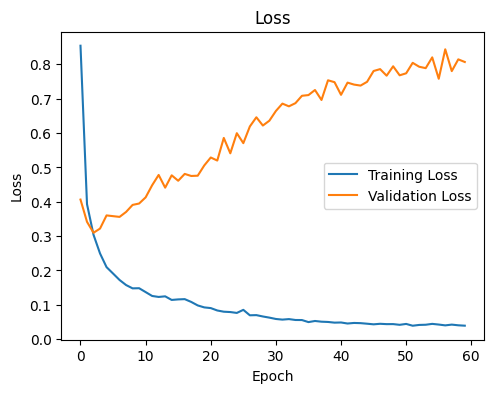

In [33]:

# Plotting the training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(gru_training_history.history['loss'], label='Training Loss')
plt.plot(gru_training_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


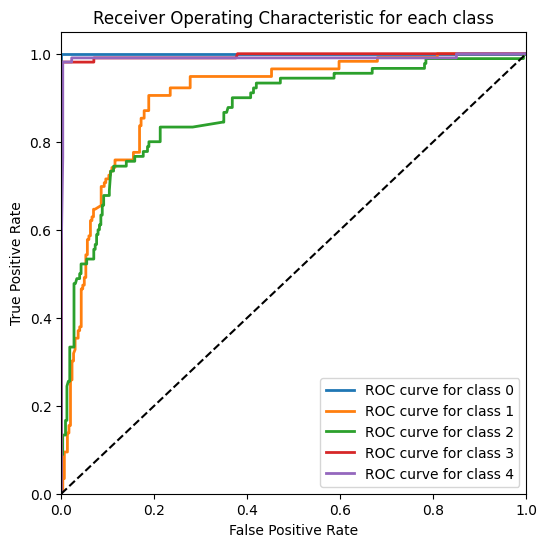

In [34]:
# Compute ROC AUC for LSTM
y_pred_lstm = gru_model.predict(X_test)
y_pred_lstm_proba = np.zeros_like(y_pred_lstm)
if len(np.unique(y_test)) == 2:
  fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_lstm[:, 1])
  roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
  print(f'\nLSTM ROC AUC: {roc_auc_lstm:.4f}')
  plt.figure(figsize=(6, 6))
  plt.plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, label='LSTM ROC curve (area = %0.2f)' % roc_auc_lstm)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('LSTM Receiver Operating Characteristic')
  plt.legend(loc="lower right")
  plt.show()
else:
    # Use LabelBinarizer to convert y_test to a binary matrix for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    fpr_lstm = dict()
    tpr_lstm = dict()
    roc_auc_lstm = dict()
    for i in range(len(np.unique(y_test))):
        fpr_lstm[i], tpr_lstm[i], _ = roc_curve(y_test_bin[:, i], y_pred_lstm[:, i])
        roc_auc_lstm[i] = auc(fpr_lstm[i], tpr_lstm[i])
    # Plot ROC curve for each class
    plt.figure(figsize=(6, 6))
    for i, class_label in enumerate(np.unique(y_test)):
        plt.plot(fpr_lstm[i], tpr_lstm[i], lw=2, label='ROC curve for class {}'.format(class_label))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for each class')
    plt.legend(loc="lower right")
    plt.show()


In [35]:

ann_model = Sequential()
ann_model.add(Embedding(vocab_size, embedding_dim, input_length=X_train.shape[1]))
ann_model.add(Flatten())
ann_model.add(Dense(128, activation='relu'))
ann_model.add(Dense(len(y.unique()), activation='softmax'))

ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
print(ann_model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
ann_training_history = ann_model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.2)

Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5621 - loss: 1.0400 - val_accuracy: 0.8239 - val_loss: 0.3874
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8263 - loss: 0.3834 - val_accuracy: 0.8448 - val_loss: 0.3220
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8847 - loss: 0.2947 - val_accuracy: 0.8418 - val_loss: 0.3490
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9129 - loss: 0.2140 - val_accuracy: 0.8687 - val_loss: 0.3219
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9419 - loss: 0.1618 - val_accuracy: 0.8687 - val_loss: 0.3318
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9426 - loss: 0.1505 - val_accuracy: 0.8716 - val_loss: 0.3363
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9335 - loss: 0.1650 - val_accuracy: 0.8776 - val_loss: 0.3421
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9529 - loss: 0.1295 - val_accuracy: 0.8716 - v

In [37]:
loss, accuracy = ann_model.evaluate(
          X_test,
          y_test
)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8109 - loss: 1.1533
Test Loss: 1.1077159643173218
Test Accuracy: 0.8210023641586304


In [38]:
y_pred_probabilities = ann_model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

report = classification_report(y_test, y_pred)
print(report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.77      0.60      0.68       116
           2       0.60      0.72      0.66        90
           3       0.98      0.98      0.98       105
           4       0.92      0.98      0.95       106

    accuracy                           0.82       419
   macro avg       0.85      0.86      0.85       419
weighted avg       0.83      0.82      0.82       419



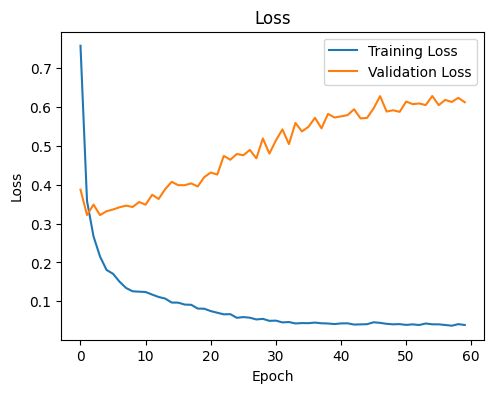

In [39]:
# Plotting the training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ann_training_history.history['loss'], label='Training Loss')
plt.plot(ann_training_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


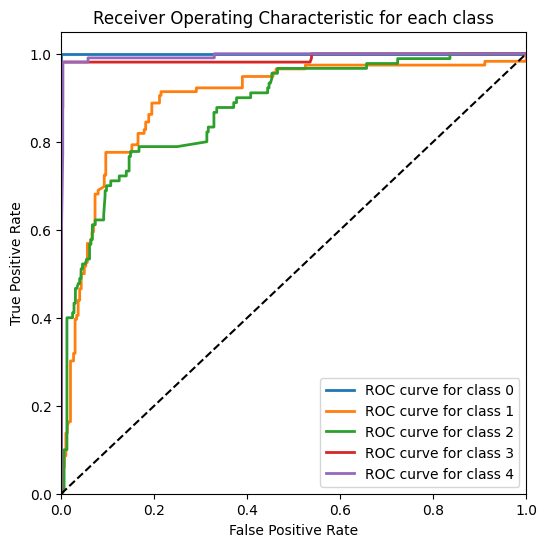

In [40]:
# Compute ROC AUC for LSTM
y_pred_lstm = ann_model.predict(X_test)
y_pred_lstm_proba = np.zeros_like(y_pred_lstm)
if len(np.unique(y_test)) == 2:
  fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_lstm[:, 1])
  roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
  print(f'\nLSTM ROC AUC: {roc_auc_lstm:.4f}')
  plt.figure(figsize=(6, 6))
  plt.plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, label='LSTM ROC curve (area = %0.2f)' % roc_auc_lstm)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('LSTM Receiver Operating Characteristic')
  plt.legend(loc="lower right")
  plt.show()
else:
    # Use LabelBinarizer to convert y_test to a binary matrix for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    fpr_lstm = dict()
    tpr_lstm = dict()
    roc_auc_lstm = dict()
    for i in range(len(np.unique(y_test))):
        fpr_lstm[i], tpr_lstm[i], _ = roc_curve(y_test_bin[:, i], y_pred_lstm[:, i])
        roc_auc_lstm[i] = auc(fpr_lstm[i], tpr_lstm[i])
    # Plot ROC curve for each class
    plt.figure(figsize=(6, 6))
    for i, class_label in enumerate(np.unique(y_test)):
        plt.plot(fpr_lstm[i], tpr_lstm[i], lw=2, label='ROC curve for class {}'.format(class_label))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for each class')
    plt.legend(loc="lower right")
    plt.show()


# GENETIC AGORITHM

### Machine Learning

In [41]:
# 1. Data Preparation
def prepare_data(df, target_column, text_column=None, max_len=100):

    X_ml = df.drop(columns=[target_column]).values
    y_ml = df[target_column].values

    # Split data for machine learning
    #X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)
    #  Don't split here.  Use the user's split.
    return X_ml, X_ml, y_ml, y_ml # Return the whole dataset, so we can use the user's split

# 2. Define Models

def get_sklearn_model(model_type='random_forest', random_state=42,
                      # RandomForestClassifier parameters
                      n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                      # MLPClassifier parameters
                      hidden_layer_sizes=(100,), activation='relu', solver='adam', alpha=0.0001, max_iter=200):

    if model_type == 'random_forest':
        return RandomForestClassifier(random_state=random_state,
                                    n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    min_samples_split=min_samples_split,
                                    min_samples_leaf=min_samples_leaf)
    elif model_type == 'mlp':
        # Suppress ConvergenceWarning for MLPClassifier if max_iter is reached
        # In a real application, you might want to increase max_iter or monitor convergence.
        return MLPClassifier(random_state=random_state,
                                 hidden_layer_sizes=hidden_layer_sizes,
                                 activation=activation,
                                 solver=solver,
                                 alpha=alpha,
                                 max_iter=max_iter)
    else:
        raise ValueError(f"Invalid model type: {model_type}. Choose 'random_forest' or 'mlp_classifier'.")

# 3. Define Genetic Algorithm Functions
def create_individual():

    return {
        'n_estimators': random.randint(10, 200),
        'max_depth': random.randint(10, 100),
        'min_samples_split': random.randint(2, 10),
        'min_samples_leaf': random.randint(1, 10),
    }


def create_dpl_individual(embedding_dim_range=(50, 300), lstm_units_range=(64, 512), lstm_dropout_range=(0.0, 0.5)):
    """
    Creates an individual (chromosome) for the genetic algorithm, optimized for LSTM.
    """
    return {
        'embedding_dim': random.randint(embedding_dim_range[0], embedding_dim_range[1]),
        'lstm_units': random.randint(lstm_units_range[0], lstm_units_range[1]),
        'lstm_dropout': random.uniform(lstm_dropout_range[0], lstm_dropout_range[1]),
    }

def create_population(population_size):
    """
    Creates a population of individuals.

    Args:
        population_size (int): The size of the population.

    Returns:
        list: A list of individuals.
    """
    return [create_individual() for _ in range(population_size)]


def calculate_fitness(individual, X_train, y_train, X_test, y_test):
    """
    Calculates the fitness of an individual.  For Random Forest, this means training a model
    with the individual's hyperparameters and evaluating its performance on the test set.

    Args:
        individual (dict): The individual to evaluate.
        X_train (np.ndarray): Training data.
        y_train (np.ndarray): Training labels.
        X_test (np.ndarray): Testing data.
        y_test (np.ndarray): True labels.

    Returns:
        float: The fitness of the individual (accuracy).
    """
    model = get_sklearn_model(model_type='random_forest',
                            n_estimators=individual['n_estimators'],
                            max_depth=individual['max_depth'],
                            min_samples_split=individual['min_samples_split'],
                            min_samples_leaf=individual['min_samples_leaf'])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)


def select_parents(population, fitnesses, num_parents=2):
    """
    Selects parents for crossover using tournament selection.

    Args:
        population (list): The population of individuals.
        fitnesses (list): The fitnesses of the individuals.
        num_parents (int): The number of parents to select.

    Returns:
        list: A list of selected parents.
    """
    parents = []
    for _ in range(num_parents):
        tournament_size = 3  # You can adjust the tournament size
        candidates_indices = np.random.choice(len(population), tournament_size, replace=False)
        best_candidate_index = max(candidates_indices, key=lambda i: fitnesses[i])
        parents.append(population[best_candidate_index])
    return parents


def crossover(parents, crossover_rate=0.8):
    """
    Performs crossover between two parents to create offspring.  For Random Forest, we're recombining
    hyperparameters.

    Args:
        parents (list): The two parent individuals.
        crossover_rate (float): The probability of crossover.

    Returns:
        dict: The offspring individual.
    """
    if random.random() < crossover_rate:
        # Simple single-point crossover for each hyperparameter
        crossover_point_n_estimators = random.randint(0, 1)
        crossover_point_max_depth = random.randint(0, 1)
        crossover_point_min_samples_split = random.randint(0, 1)
        crossover_point_min_samples_leaf = random.randint(0, 1)


        offspring = {
            'n_estimators': parents[0]['n_estimators'] if crossover_point_n_estimators == 0 else parents[1]['n_estimators'],
            'max_depth': parents[0]['max_depth'] if crossover_point_max_depth == 0 else parents[1]['max_depth'],
            'min_samples_split': parents[0]['min_samples_split'] if crossover_point_min_samples_split == 0 else parents[1]['min_samples_split'],
            'min_samples_leaf': parents[0]['min_samples_leaf'] if crossover_point_min_samples_leaf == 0 else parents[1]['min_samples_leaf'],
        }
        return offspring
    else:
        return deepcopy(random.choice(parents))


def mutate(individual, mutation_rate=0.1):
    """
    Mutates an individual by randomly changing its hyperparameters.

    Args:
        individual (dict): The individual to mutate.
        mutation_rate (float): The probability of mutation for each hyperparameter.

    Returns:
        dict: The mutated individual.
    """
    mutated_individual = deepcopy(individual)
    if random.random() < mutation_rate:
        mutated_individual['n_estimators'] = random.randint(10, 200)
    if random.random() < mutation_rate:
        mutated_individual['max_depth'] = random.randint(10, 100)
    if random.random() < mutation_rate:
        mutated_individual['min_samples_split'] = random.randint(2, 10)
    if random.random() < mutation_rate:
        mutated_individual['min_samples_leaf'] = random.randint(1, 10)
    return mutated_individual


def create_next_generation(population, fitnesses, population_size):
    """
    Creates the next generation of individuals.

    Args:
        population (list): The current population.
        fitnesses (list): The fitnesses of the individuals.
        population_size (int): The desired size of the next generation.

    Returns:
        list: The next generation of individuals.
    """
    next_generation = []
    for _ in range(population_size):
        parents = select_parents(population, fitnesses)
        offspring = crossover(parents)
        mutated_offspring = mutate(offspring)
        next_generation.append(mutated_offspring)
    return next_generation

def get_lstm_model(vocab_size, embedding_dim, lstm_units, lstm_dropout, output_dim):
    """
    Define and return the LSTM model.

    Args:
        vocab_size (int): Vocabulary size.
        embedding_dim (int): Dimension of the embedding layer.
        lstm_units (int): Number of units in the LSTM layer.
        lstm_dropout (float): Dropout rate in the LSTM layer.
        output_dim (int): Dimension of the output layer.

    Returns:
        Sequential: A compiled LSTM model.
    """
    lstm_model = Sequential()
    lstm_model.add(Embedding(vocab_size, embedding_dim))
    lstm_model.add(LSTM(lstm_units, dropout=lstm_dropout))
    lstm_model.add(Dense(output_dim, activation='softmax'))
    lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return lstm_model

# 5. Main Function to Run Genetic Algorithm
def run_genetic_algorithm(df, target_column,  X_train, X_test, y_train, y_test, population_size=10, generations=10):
    """
    Runs the genetic algorithm to optimize the Random Forest model.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_column (str): The name of the target column.
        population_size (int): The size of the population.
        generations (int): The number of generations to run.
        X_train: User's training data
        X_test: User's test data
        y_train: User's training labels
        y_test: User's test labels

    Returns:
        dict: The best individual found by the genetic algorithm.
    """
    # 1. Prepare the data
    #X_train_ml, X_test_ml, y_train_ml, y_test_ml = prepare_data(df, target_column)
    # Don't use this, use the user's split.
    X_train_ml, X_test_ml, y_train_ml, y_test_ml = X_train, X_test, y_train, y_test # Rename

    # 2. Create the initial population
    population = create_population(population_size)

    # 3. Run the genetic algorithm
    best_individual = None
    best_fitness = -1
    for generation in range(generations):
        # 4. Evaluate the fitness of each individual
        fitnesses = [calculate_fitness(individual, X_train_ml, y_train_ml, X_test_ml, y_test_ml) for individual in population]

        # 5. Find the best individual
        current_best_index = np.argmax(fitnesses)
        current_best_fitness = fitnesses[current_best_index]
        if current_best_fitness > best_fitness:
            best_fitness = current_best_fitness
            best_individual = population[current_best_index]
        print(f'Generation: {generation+1}, Best Fitness: {best_fitness:.4f}')

        # 6. Create the next generation
        population = create_next_generation(population, fitnesses, population_size)

    return best_individual


def get_best_lstm_individual(best_individual):
    """
    Returns the best LSTM individual from the best overall individual.

    Args:
        best_individual (dict): The best individual found by the genetic algorithm.

    Returns:
        dict: A dictionary containing the LSTM hyperparameters from the best individual.
    """
    return {
        'lstm_units': best_individual['lstm_units'],
        'lstm_dropout': best_individual['lstm_dropout'],
    }


In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, precision_recall_curve
import random
from copy import deepcopy
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report

In [43]:
best_individual = run_genetic_algorithm(df, 'DIAGNOSIS', X_train, X_test, y_train, y_test, population_size=20, generations=20)

print('\nBest Individual:', best_individual)

Generation: 1, Best Fitness: 0.8544
Generation: 2, Best Fitness: 0.8544
Generation: 3, Best Fitness: 0.8544
Generation: 4, Best Fitness: 0.8544
Generation: 5, Best Fitness: 0.8568
Generation: 6, Best Fitness: 0.8568
Generation: 7, Best Fitness: 0.8568
Generation: 8, Best Fitness: 0.8568
Generation: 9, Best Fitness: 0.8592
Generation: 10, Best Fitness: 0.8592
Generation: 11, Best Fitness: 0.8592
Generation: 12, Best Fitness: 0.8592
Generation: 13, Best Fitness: 0.8592
Generation: 14, Best Fitness: 0.8592
Generation: 15, Best Fitness: 0.8592
Generation: 16, Best Fitness: 0.8592
Generation: 17, Best Fitness: 0.8592
Generation: 18, Best Fitness: 0.8592
Generation: 19, Best Fitness: 0.8592
Generation: 20, Best Fitness: 0.8592

Best Individual: {'n_estimators': 196, 'max_depth': 90, 'min_samples_split': 8, 'min_samples_leaf': 2}


In [44]:
# Get the best model
best_model = get_sklearn_model(model_type='random_forest',
                                    n_estimators=best_individual['n_estimators'],
                                    max_depth=best_individual['max_depth'],
                                    min_samples_split=best_individual['min_samples_split'],
                                    min_samples_leaf=best_individual['min_samples_leaf'])

In [45]:
# Train and evaluate the model
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Best Model Accuracy: {accuracy:.4f}')

rf_report = classification_report(y_test, y_pred) # And calculate this.
print(rf_report)

Best Model Accuracy: 0.8592
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.76      0.78      0.77       116
           2       0.71      0.67      0.69        90
           3       0.99      0.98      0.99       105
           4       0.95      0.98      0.97       106

    accuracy                           0.86       419
   macro avg       0.88      0.88      0.88       419
weighted avg       0.86      0.86      0.86       419



In [46]:
# Get the best model
best_mlp_model = get_sklearn_model(model_type='mlp',
                                    n_estimators=best_individual['n_estimators'],
                                    max_depth=best_individual['max_depth'],
                                    min_samples_split=best_individual['min_samples_split'],
                                    min_samples_leaf=best_individual['min_samples_leaf'])

In [47]:
# Train and evaluate the model
best_mlp_model.fit(X_train, y_train)
y_pred = best_mlp_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Best Model Accuracy: {accuracy:.4f}')

mlp_report = classification_report(y_test, y_pred) # And calculate this.
print(mlp_report)

Best Model Accuracy: 0.7804
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.79      0.53      0.63       116
           2       0.57      0.66      0.61        90
           3       0.94      0.98      0.96       105
           4       0.80      0.98      0.88       106

    accuracy                           0.78       419
   macro avg       0.62      0.63      0.62       419
weighted avg       0.78      0.78      0.77       419



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Deep Learning

In [48]:

# 1. Data Preparation
def prepare_data(df, target_column, text_column=None, max_len=100):
    """
    Prepares data for deep learning models.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_column (str): The name of the target column.
        text_column (str, optional): The name of the text column (for LSTM). Defaults to None.
        max_len (int): Maximum sequence length for padding.

    Returns:
        tuple: A tuple containing:
            - X_train_lstm (np.ndarray): Training data for LSTM.
            - X_test_lstm (np.ndarray): Testing data for LSTM.
            - y_train_lstm (np.ndarray): Training labels for LSTM.
            - y_test_lstm (np.ndarray): Testing labels for LSTM.
    """
    X_lstm = df[text_column].values
    y_lstm = df[target_column].values

    # Tokenize and pad sequences for LSTM
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(X_lstm)
    X_lstm = tokenizer.texts_to_sequences(X_lstm)
    X_lstm = pad_sequences(X_lstm, maxlen=max_len)
    vocab_size = len(tokenizer.word_index) + 1

    # Split data for LSTM
    # X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)
    # No longer splitting, using pre-split data

    return X_lstm, vocab_size, tokenizer # Return processed data, and tokenizer

# 2. Define Models
def get_sklearn_model(model_type='random_forest', random_state=42, n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1):
    """
    Returns an sklearn model instance.

    Args:
        model_type (str): The type of sklearn model ('random_forest').
        random_state (int): Random state for the model.
        n_estimators (int): Number of trees in the forest.
        max_depth (int): The maximum depth of the tree.
        min_samples_split (int): The minimum number of samples required to split an internal node.
        min_samples_leaf (int): The minimum number of samples required to be at a leaf node.

    Returns:
        An sklearn model instance.
    """
    if model_type == 'random_forest':
        return RandomForestClassifier(random_state=random_state,
                                    n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    min_samples_split=min_samples_split,
                                    min_samples_leaf=min_samples_leaf)
    else:
        raise ValueError(f"Invalid model type: {model_type}")

def get_lstm_model(model_type='lstm', random_state=42, vocab_size=None, embedding_dim=100, lstm_units=128, lstm_dropout=0.2, output_dim=4):
    """
    Define and return the LSTM model.

    Args:
        model_type (str): The type of model ('lstm').
        random_state (int): Random state for the model.
        vocab_size (int): Vocabulary size.
        embedding_dim (int): Dimension of the embedding layer.
        lstm_units (int): Number of units in the LSTM layer.
        lstm_dropout (float): Dropout rate in the LSTM layer.
        output_dim (int): Dimension of the output layer.

    Returns:
        Sequential: A compiled LSTM model.
    """
    if model_type == 'lstm':
      lstm_model = Sequential()
      lstm_model.add(Embedding(vocab_size, embedding_dim, input_length=X_train.shape[1])) # Use X_train.shape[1]
      lstm_model.add(LSTM(128))  # You can adjust the number of units
      lstm_model.add(Dense(len(y.unique()), activation='softmax'))  # Output layer

      # Compile the model
      lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

      return lstm_model
    elif model_type == "ann":
      ann_model = Sequential()
      ann_model.add(Embedding(vocab_size, embedding_dim, input_length=X_train.shape[1])) # Use X_train.shape[1]
      ann_model.add(Flatten())  # Flatten the output of the embedding layer
      ann_model.add(Dense(128, activation='relu'))  # Add a dense layer
      ann_model.add(Dense(len(y.unique()), activation='softmax'))  # Output layer

      # Compile the model
      ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
      return ann_model
    else:
        raise ValueError(f"Invalid model type: {model_type}")

# 3. Define Genetic Algorithm Functions
def create_individual(embedding_dim_range=(50, 300), lstm_units_range=(64, 512), lstm_dropout_range=(0.0, 0.5)):
    """
    Creates an individual (chromosome) for the genetic algorithm, optimized for LSTM.
    """
    return {
        'embedding_dim': random.randint(embedding_dim_range[0], embedding_dim_range[1]),
        'lstm_units': random.randint(lstm_units_range[0], lstm_units_range[1]),
        'lstm_dropout': random.uniform(lstm_dropout_range[0], lstm_dropout_range[1]),
    }

def create_population(population_size):
    """
    Creates a population of individuals.

    Args:
        population_size (int): The size of the population.

    Returns:
        list: A list of individuals.
    """
    return [create_individual() for _ in range(population_size)]

def calculate_fitness(individual, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, vocab_size, output_dim):
    """
    Calculates the fitness of an individual for LSTM model.

    Args:
        individual (dict): The individual to evaluate.
        X_train_lstm (np.ndarray): Training data for LSTM.
        y_train_lstm (np.ndarray): Training labels for LSTM.
        X_test_lstm (np.ndarray): Testing data for LSTM.
        y_test_lstm (np.ndarray): True labels for LSTM.
        vocab_size (int): Vocabulary size.
        output_dim (int): Output dimension

    Returns:
        float: The fitness of the individual (accuracy).
    """
    lstm_model = get_lstm_model(model_type='lstm',
                                vocab_size=vocab_size,
                                embedding_dim=individual['embedding_dim'],
                                lstm_units=individual['lstm_units'],
                                lstm_dropout=individual['lstm_dropout'],
                                output_dim=output_dim)
    lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, verbose=0)  # Train silently.
    y_pred_lstm = lstm_model.predict(X_test_lstm)
    y_pred_lstm = np.argmax(y_pred_lstm, axis=1)
    accuracy_lstm = accuracy_score(y_test_lstm, y_pred_lstm)
    return accuracy_lstm

def select_parents(population, fitnesses, num_parents=2):
    """
    Selects parents for crossover using tournament selection.

    Args:
        population (list): The population of individuals.
        fitnesses (list): The fitnesses of the individuals.
        num_parents (int): The number of parents to select.

    Returns:
        list: A list of selected parents.
    """
    parents = []
    for _ in range(num_parents):
        tournament_size = 3
        candidates_indices = np.random.choice(len(population), tournament_size, replace=False)
        best_candidate_index = max(candidates_indices, key=lambda i: fitnesses[i])
        parents.append(population[best_candidate_index])
    return parents

def crossover(parents, crossover_rate=0.8):
    """
    Performs crossover between two parents to create offspring.

    Args:
        parents (list): The two parent individuals.
        crossover_rate (float): The probability of crossover.

    Returns:
        dict: The offspring individual.
    """
    if random.random() < crossover_rate:
        crossover_point_embedding_dim = random.randint(0, 1)
        crossover_point_lstm_units = random.randint(0, 1)
        crossover_point_lstm_dropout = random.randint(0, 1)

        offspring = {
            'embedding_dim': parents[0]['embedding_dim'] if crossover_point_embedding_dim == 0 else parents[1]['embedding_dim'],
            'lstm_units': parents[0]['lstm_units'] if crossover_point_lstm_units == 0 else parents[1]['lstm_units'],
            'lstm_dropout': parents[0]['lstm_dropout'] if crossover_point_lstm_dropout == 0 else parents[1]['lstm_dropout'],
        }
        return offspring
    else:
        return deepcopy(random.choice(parents))

def mutate(individual, mutation_rate=0.1):
    """
    Mutates an individual by randomly changing its hyperparameters.

    Args:
        individual (dict): The individual to mutate.
        mutation_rate (float): The probability of mutation for each hyperparameter.

    Returns:
        dict: The mutated individual.
    """
    mutated_individual = deepcopy(individual)
    if random.random() < mutation_rate:
        mutated_individual['embedding_dim'] = random.randint(50, 300)
    if random.random() < mutation_rate:
        mutated_individual['lstm_units'] = random.randint(64, 512)
    if random.random() < mutation_rate:
        mutated_individual['lstm_dropout'] = random.uniform(0.0, 0.5)
    return mutated_individual

def create_next_generation(population, fitnesses, population_size):
    """
    Creates the next generation of individuals.

    Args:
        population (list): The current population.
        fitnesses (list): The fitnesses of the individuals.
        population_size (int): The desired size of the next generation.

    Returns:
        list: The next generation of individuals.
    """
    next_generation = []
    for _ in range(population_size):
        parents = select_parents(population, fitnesses)
        offspring = crossover(parents)
        mutated_offspring = mutate(offspring)
        next_generation.append(mutated_offspring)
    return next_generation

# 5. Main Function to Run Genetic Algorithm
def run_genetic_algorithm(X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, vocab_size, output_dim, population_size=10, generations=10):
    """
    Runs the genetic algorithm to optimize the LSTM model.

    Args:
        X_train_lstm (np.ndarray): Training data for LSTM.
        X_test_lstm (np.ndarray): Testing data for LSTM.
        y_train_lstm (np.ndarray): Training labels for LSTM.
        y_test_lstm (np.ndarray): Testing labels for LSTM.
        vocab_size (int): Vocabulary size.
        output_dim (int): The number of unique classes in the target variable.
        population_size (int): The size of the population.
        generations (int): The number of generations to run.

    Returns:
        dict: The best individual found by the genetic algorithm.
    """
    # 1. Prepare the data
    # X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, vocab_size, tokenizer = prepare_data(df, target_column, text_column, max_len)
    # output_dim = len(np.unique(y_train_lstm)) # Calculate outside the loop - NO LONGER NEEDED

    # 2. Create the initial population
    population = create_population(population_size)
    best_individual = None
    best_fitness = -1

    # 3. Run the genetic algorithm
    for generation in range(generations):
        # 4. Evaluate the fitness of each individual
        fitnesses = [calculate_fitness(individual, X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm, vocab_size, output_dim) for individual in population]

        # 5. Find the best individual
        current_best_index = np.argmax(fitnesses)
        current_best_fitness = fitnesses[current_best_index]
        if current_best_fitness > best_fitness:
            best_fitness = current_best_fitness
            best_individual = population[current_best_index]
        print(f'Generation: {generation+1}, Best Fitness: {best_fitness:.4f}')

        # 6. Create the next generation
        population = create_next_generation(population, fitnesses, population_size)

    return best_individual

In [49]:
# run_genetic_algorithm(df, 'DIAGNOSIS', X_train, X_test, y_train, y_test, population_size=10, generations=10)

# print('\nBest Individual:', best_individual)

In [50]:
vocab_size = 1000
output_dim = 4

best_hyperparameters = {'embedding_dim': 166, 'lstm_units': 19, 'lstm_dropout': 0.1}  # Use values from best_individual
best_lstm_model = get_lstm_model(model_type='lstm',
                                    vocab_size=vocab_size,
                                    embedding_dim=best_hyperparameters['embedding_dim'],
                                    lstm_units=best_hyperparameters['lstm_units'],
                                    lstm_dropout=best_hyperparameters['lstm_dropout'],
                                    output_dim=output_dim)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [51]:
best_lstm_model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.2)


Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.3664 - loss: 1.3470 - val_accuracy: 0.7194 - val_loss: 0.6342
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7426 - loss: 0.5497 - val_accuracy: 0.8269 - val_loss: 0.4026
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8311 - loss: 0.4035 - val_accuracy: 0.8328 - val_loss: 0.3584
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8595 - loss: 0.3432 - val_accuracy: 0.8358 - val_loss: 0.3558
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8750 - loss: 0.2848 - val_accuracy: 0.8537 - val_loss: 0.3542
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9052 - loss: 0.2471 - val_accuracy: 0.8448 - val_loss: 0.3401
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8972 - loss: 0.2439 - val_accuracy: 0.8537 - val_loss: 0.3673
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9073 - loss: 0.2282 - val_accuracy: 0.8537 - v

In [52]:
y_pred_lstm = best_lstm_model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
print(f'Trained LSTM Model Accuracy: {accuracy_lstm:.4f}')
lstm_report = classification_report(y_test, y_pred_lstm)
print(lstm_report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Trained LSTM Model Accuracy: 0.8329
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.75      0.71      0.73       116
           2       0.64      0.64      0.64        90
           3       0.99      0.98      0.99       105
           4       0.92      0.98      0.95       106

    accuracy                           0.83       419
   macro avg       0.86      0.86      0.86       419
weighted avg       0.83      0.83      0.83       419



In [53]:
best_ann_model = get_lstm_model(model_type='ann',
                                    vocab_size=vocab_size,
                                    embedding_dim=best_hyperparameters['embedding_dim'],
                                    lstm_units=best_hyperparameters['lstm_units'],
                                    lstm_dropout=best_hyperparameters['lstm_dropout'],
                                    output_dim=output_dim)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [54]:
best_lstm_model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.2)

Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9777 - loss: 0.0546 - val_accuracy: 0.8687 - val_loss: 0.6950
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9854 - loss: 0.0443 - val_accuracy: 0.8746 - val_loss: 0.7545
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9807 - loss: 0.0446 - val_accuracy: 0.8687 - val_loss: 0.7301
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9893 - loss: 0.0413 - val_accuracy: 0.8776 - val_loss: 0.7494
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9846 - loss: 0.0372 - val_accuracy: 0.8746 - val_loss: 0.7334
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9778 - loss: 0.0560 - val_accuracy: 0.8716 - val_loss: 0.7771
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9872 - loss: 0.0409 - val_accuracy: 0.8776 - val_loss: 0.7425
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9860 - loss: 0.0348 - val_accuracy: 0.8687 - v

In [55]:
y_pred_lstm = best_lstm_model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
print(f'Trained LSTM Model Accuracy: {accuracy_lstm:.4f}')
lstm_report = classification_report(y_test, y_pred_lstm)
print(lstm_report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Trained LSTM Model Accuracy: 0.8210
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.77      0.62      0.69       116
           2       0.61      0.70      0.65        90
           3       0.98      0.98      0.98       105
           4       0.91      0.98      0.95       106

    accuracy                           0.82       419
   macro avg       0.85      0.86      0.85       419
weighted avg       0.82      0.82      0.82       419



### Ensemble Learning

In [56]:
# Assuming rf_model and lstm_model are already trained

def ensemble_predict(rf_model, lstm_model, X_test):
    """
    Combines predictions from a Random Forest and an LSTM model using soft voting.

    Args:
        rf_model: Trained Random Forest model.
        lstm_model: Trained LSTM model.
        X_test: Test data.

    Returns:
        numpy.ndarray: Combined predictions.
    """
    # Get predictions from both models
    rf_predictions = rf_model.predict_proba(X_test)  # Probabilities for each class
    lstm_predictions = lstm_model.predict(X_test)
    lstm_predictions = np.argmax(lstm_predictions, axis=1) # Convert back to class labels
    #Need to convert the LSTM predictions to probabilities to match the rf_predictions
    from sklearn.preprocessing import LabelBinarizer
    lb = LabelBinarizer()
    lb.fit(y_train) #y_train from when you trained your LSTM
    lstm_predictions_proba = lb.transform(lstm_predictions)


    # Combine predictions using soft voting (weighted average)
    ensemble_predictions = (rf_predictions + lstm_predictions_proba) / 2  # Simple average

    # Get the class with the highest probability
    ensemble_predictions = np.argmax(ensemble_predictions, axis=1)
    return ensemble_predictions


In [57]:
ensemble_preds = ensemble_predict(best_model, best_lstm_model, X_test)

# Evaluate the ensemble's performance
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, ensemble_preds)

print(f"Ensemble Accuracy: {accuracy}")
print(classification_report(y_test, ensemble_preds))


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Ensemble Accuracy: 0.8210023866348448
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.77      0.62      0.69       116
           2       0.61      0.70      0.65        90
           3       0.98      0.98      0.98       105
           4       0.91      0.98      0.95       106

    accuracy                           0.82       419
   macro avg       0.85      0.86      0.85       419
weighted avg       0.82      0.82      0.82       419



In [58]:
user_input = [
    "Limp at birth", "Prematurity", "BABY IS NOT SUCKING WELL,FAST BREATHING", "FAILURE TO GAIN WEIGHT,FULLY AWAKE IN MOST OCCASION,OFTEN CRIES BARELY 30MINS AFTER BREAST FEEDING,SKIN RAHSES",
    "I am eating"
]

user_df = pd.DataFrame(user_input, columns=['symptoms'])


user_df["input-symptoms"] = user_df["symptoms"].apply(lambda text: cdsSystem.convertTextToVec(text))

stacked_symptoms = cdsSystem.stackVector(user_df["input-symptoms"])

predictions = rf_model.predict(stacked_symptoms)

predictions
cds_diagnosis = ["Uncategorized", "Neonatal Sepsis", "Probable NNS", "Late NNS", "Early NNS"]

for prediction in predictions:

  print("The diagonized ailment is: ", cds_diagnosis[prediction])

The diagonized ailment is:  Probable NNS
The diagonized ailment is:  Neonatal Sepsis
The diagonized ailment is:  Neonatal Sepsis
The diagonized ailment is:  Late NNS
The diagonized ailment is:  Neonatal Sepsis


In [59]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(X_train)

IsolationForest(random_state=42)

In [60]:
anomaly_score = iso_forest.decision_function(user_symptoms_pad)
anomaly_prediction = iso_forest.predict(user_symptoms_pad)

NameError: name 'user_symptoms_pad' is not defined

In [8]:
import joblib

In [9]:
joblib.dump(rf_model, 'random_forest_model.joblib')

['random_forest_model.joblib']

In [12]:
loaded_model = joblib.load('random_forest_model.joblib')

In [13]:
user_input = [
    "Limp at birth", "Prematurity", "BABY IS NOT SUCKING WELL,FAST BREATHING", "FAILURE TO GAIN WEIGHT,FULLY AWAKE IN MOST OCCASION,OFTEN CRIES BARELY 30MINS AFTER BREAST FEEDING,SKIN RAHSES",
    "I am eating"
]

user_df = pd.DataFrame(user_input, columns=['symptoms'])


user_df["input-symptoms"] = user_df["symptoms"].apply(lambda text: cdsSystem.convertTextToVec(text))

stacked_symptoms_2 = cdsSystem.stackVector(user_df["input-symptoms"])

print(stacked_symptoms_2)
user_df

[[ 2.73328751e-01 -5.78991532e-01  4.24568176e-01 -4.50257212e-01
  -6.28123641e-01  1.18936621e-01  1.77202389e-01 -1.00324310e-01
   5.15515506e-01  6.73410669e-02  4.55823749e-01 -8.32632124e-01
  -8.29099476e-01  1.07379287e-01  1.33898973e-01 -2.88160861e-01
  -3.33134741e-01 -1.18595839e-01  5.18811703e-01  3.60620528e-01
  -6.36361182e-01  7.37493858e-02 -9.50305223e-01 -3.79873902e-01
   4.26373512e-01 -2.47878492e-01  1.71834424e-01  3.54098201e-01
  -2.93892056e-01  6.09533191e-01 -1.35150298e-01 -1.84140250e-01
   5.59957862e-01 -7.99444318e-02 -9.52238441e-02 -3.00009936e-01
   4.32845443e-01  7.64353335e-01  8.35415781e-01 -2.44312644e-01
  -8.68037522e-01 -1.68054804e-01  4.93053682e-02 -2.06596017e-01
   6.37150109e-02  1.37697235e-01 -4.10280675e-01 -1.87598467e-01
   1.45525411e-01 -3.08978230e-01 -3.38141769e-01 -5.90575039e-01
  -1.44426063e-01 -2.39658251e-01 -6.93789721e-01 -1.50245905e-01
  -4.47781354e-01 -1.70147315e-01  5.11528969e-01 -4.46389049e-01
  -3.41848

,symptoms,input-symptoms
0,Limp at birth,"[0.27332875, -0.57899153, 0.42456818, -0.45025..."
1,Prematurity,"[-0.8604678, -0.12185934, -1.1031686, 0.076027..."
2,"BABY IS NOT SUCKING WELL,FAST BREATHING","[0.0713343, -0.1655202, 0.3888812, 0.17194825,..."
3,"FAILURE TO GAIN WEIGHT,FULLY AWAKE IN MOST OCC...","[0.32559958, -0.19292173, -0.072918706, -0.320..."
4,I am eating,"[-0.9614935, -0.24485736, -0.09240621, 0.34587..."


In [14]:
pred=loaded_model.predict(stacked_symptoms_2)

pred

array([2, 2, 1, 3, 2])

In [19]:
cds_diagnosis = ["Uncategorized", "Neonatal Sepsis", "Probable NNS", "Late NNS", "Early NNS"]

for prediction in pred:

  print("The diagonized ailment is: ", cds_diagnosis[prediction])

The diagonized ailment is:  Probable NNS
The diagonized ailment is:  Probable NNS
The diagonized ailment is:  Neonatal Sepsis
The diagonized ailment is:  Late NNS
The diagonized ailment is:  Probable NNS
